<All keys matched successfully>


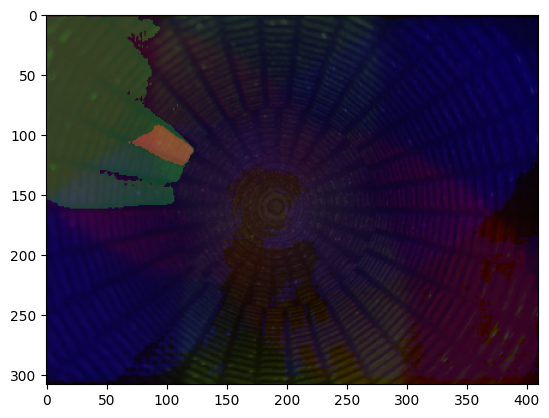

In [31]:
from edge_sam import SamPredictor, sam_model_registry
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import cv2
import os

def overlay_masks_on_image(img, masks, alpha=0.4):
    # Create a figure and axis
    fig, ax = plt.subplots()

    # Show the original image
    ax.imshow(img)

    for i in [2,1,0]: #range(masks.shape[0]):  # Iterate over each mask channel
        mask = np.zeros([*masks[i].shape,3])
        mask[...,i] = masks[i]
        mask = mask.astype(int)*255

        # Overlay the mask on the image
        ax.imshow(mask, alpha=alpha)  # Use the mask with transparency

    # Display the image with overlays
    plt.show()


img_array = cv2.imread(os.path.join(f"test_Color.png"))
sam = sam_model_registry["edge_sam"](checkpoint="EdgeSAM/checkpoints/edge_sam_3x.pth")
predictor = SamPredictor(sam)
predictor.set_image(img_array)
masks, _, _ = predictor.predict(point_coords=np.array([[100,100]]),
point_labels=np.array([1]))

overlay_masks_on_image(img_array, masks)


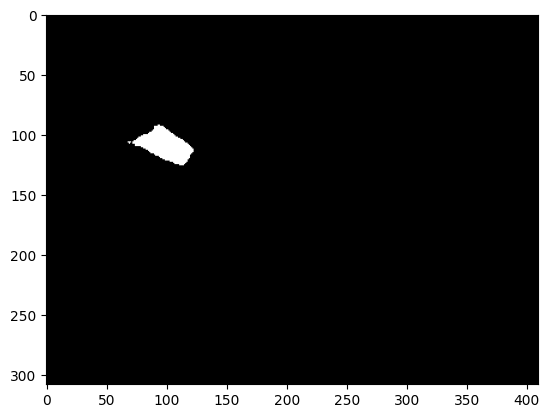

In [22]:
masks[0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])